In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

visa_df=pd.read_csv(r"C:\Users\vinit\Documents\Naresh IT\Datafiles\visadataset.csv")
num=visa_df.select_dtypes(exclude='object').columns
cat=visa_df.select_dtypes(include='object').columns
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


**Why scaling**

- Scaling preserve the numerical stability across the columns

    - Ex:- Age : 20  Salary : 50000  Exp: 2

    - different columns having the different scale(limit)

    - we want to keep all the columns under same limit

    - if we dont keep under same scale some ML algorithms feels salary is the important column
        
            - because of the highest value

- **faster training**

        - Some of ML algorithms like **KNN,KMEANS,SVM** are distance based algorithms

        - if we lower the values the calculations are fast

        - In every Model development will do math calculations

        - In order to increase the fastness(optimization) scaling is very helpful

**Z scale**

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSCItQbxeibj8AE75mx3ApWbZZIjzbsCGgDsjfg7aWzKg&s=10"/>

In [83]:
visa_df['prevailing_wage']

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64

In [84]:
wage_data = visa_df['prevailing_wage']
# step1: wage_mean=wage_data.mean()
# step-2: wage_sd
# step-3: Nr=wage_data-wage_mean
# step-4: Nr/wage_sd

In [85]:
wage_data = visa_df['prevailing_wage']
wage_mean=wage_data.mean()
wage_mean

np.float64(74455.81459209183)

In [86]:
wage_sd=wage_data.std()
wage_sd

52815.94232687357

In [87]:
Nr=wage_data-wage_mean
wage_z=Nr/wage_sd
wage_z

0       -1.398510
1        0.169832
2        0.919060
3        0.169991
4        1.428576
           ...   
25475    0.049923
25476    3.876083
25477    1.360253
25478    0.221504
25479   -0.067762
Name: prevailing_wage, Length: 25480, dtype: float64

In [88]:
wage_mean=wage_data.mean()
wage_sd=wage_data.std()
Nr=wage_data-wage_mean
wage_z=Nr/wage_sd

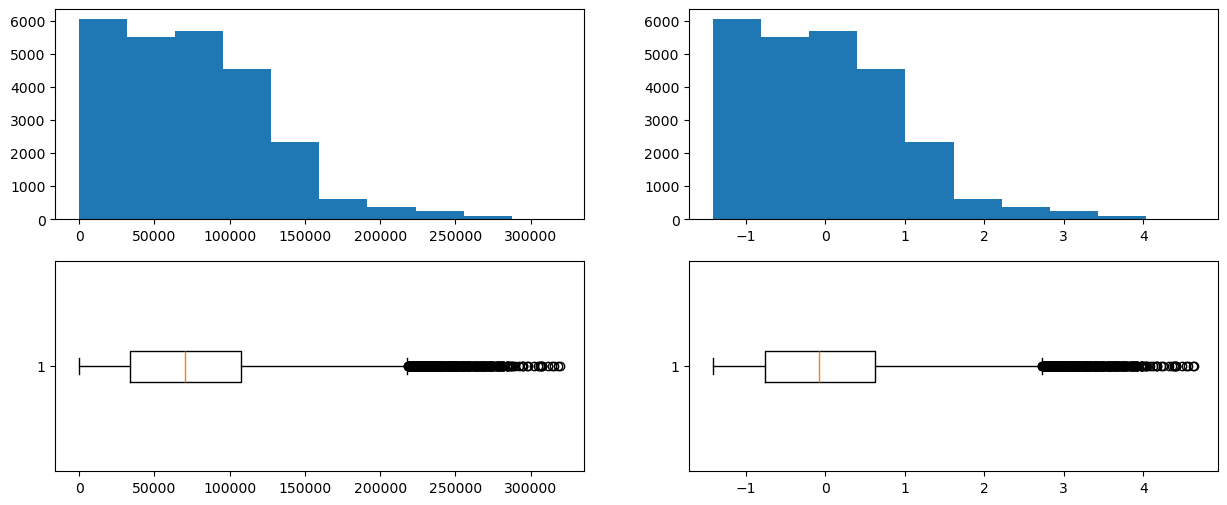

In [89]:
# old_data  : wage_data
# z_data    : wage_z
plt.figure(figsize=(15,6))
plt.subplot(2,2,1).hist(wage_data)
plt.subplot(2,2,2).hist(wage_z)
plt.subplot(2,2,3).boxplot(wage_data,vert=False)
plt.subplot(2,2,4).boxplot(wage_z,vert=False)
plt.show()

- sklearn

    - preprocessing

        - StandardScalar

            - fit_transform

In [90]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
wage_data_ss=ss.fit_transform(visa_df[['prevailing_wage']])
visa_df['prevailing_wage']=wage_data_ss
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,-1.398537,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,0.169835,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,0.919079,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,0.169994,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,1.428604,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,0.049924,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,3.876159,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,1.360280,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,0.221509,Year,Y,Certified


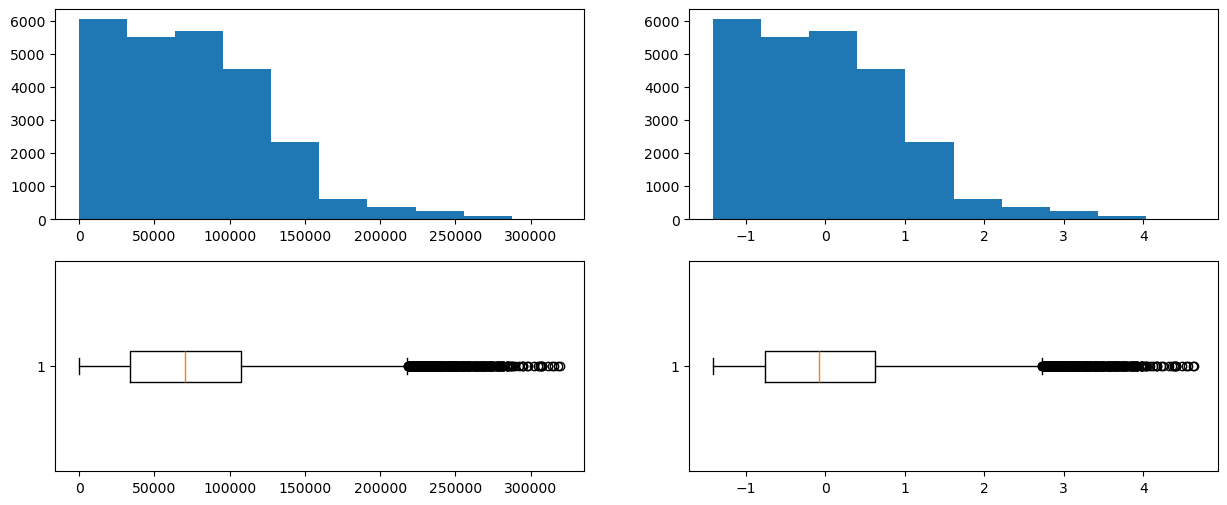

In [91]:
plt.figure(figsize=(15,6))
plt.subplot(2,2,1).hist(wage_data)
plt.subplot(2,2,2).hist(wage_z)
plt.subplot(2,2,3).boxplot(wage_data,vert=False)
plt.subplot(2,2,4).boxplot(wage_z,vert=False)
plt.show()

**Normalization**

In [92]:
# step-1: wage_min
# step-2: wage_max
# step-3: Nr=wage_data-wage_min
# step-4: Dr=wage_max-wage_min
# step-5: wage_norm=Nr/Dr

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQq95bgzuFluFTGIQ36zg48ceGSVtPhDTUdpI15kZoYvQ&s=10"/> 

- **StandardScalar is called as a Z score**
- **MinMaxScalar is called as Norm 0 to 1**

In [93]:
wage_data = visa_df['prevailing_wage']
wage_min = wage_data.min()
wage_max = wage_data.max()
Nr=wage_data-wage_min
Dr=wage_max-wage_min
wage_norm=Nr/Dr
wage_norm

0        0.001849
1        0.261345
2        0.385312
3        0.261371
4        0.469616
           ...   
25475    0.241505
25476    0.874579
25477    0.458311
25478    0.269895
25479    0.222033
Name: prevailing_wage, Length: 25480, dtype: float64

In [95]:
from sklearn.preprocessing import MinMaxScaler
mms=MinMaxScaler()
wage_data_mms=mms.fit_transform(visa_df[['prevailing_wage']])
visa_df['prevailing_wage']=wage_data_mms
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,0.001849,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,0.261345,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,0.385312,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,0.261371,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,0.469616,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,0.241505,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,0.874579,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,0.458311,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,0.269895,Year,Y,Certified
